In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
obs_grid = pd.read_csv(r'U:\Guests\Pandit\_upload\2026-02-20\target_coordinates_EPSG_3034.txt', sep = '\t')
obs_grid.head()

,x,y
0,3772500,2702500
1,3777500,2702500
2,3782500,2702500
3,3787500,2702500
4,3792500,2702500


In [3]:
import contextily as ctx
def obs_gdf(obs_grid):
    geometry = gpd.points_from_xy(obs_grid['x'].values, obs_grid['y'].values)
    gdf = gpd.GeoDataFrame(obs_grid, geometry = geometry, crs = 'EPSG:3034')
    gdf_basemap = gdf.to_crs('EPSG: 3857') # web mercator
    fig, ax = plt.subplots(figsize = (9,9))
    gdf_basemap.plot(ax = ax, color ='g', markersize = 1)
    ctx.add_basemap(ax , source = ctx.providers.OpenStreetMap.DE)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
   

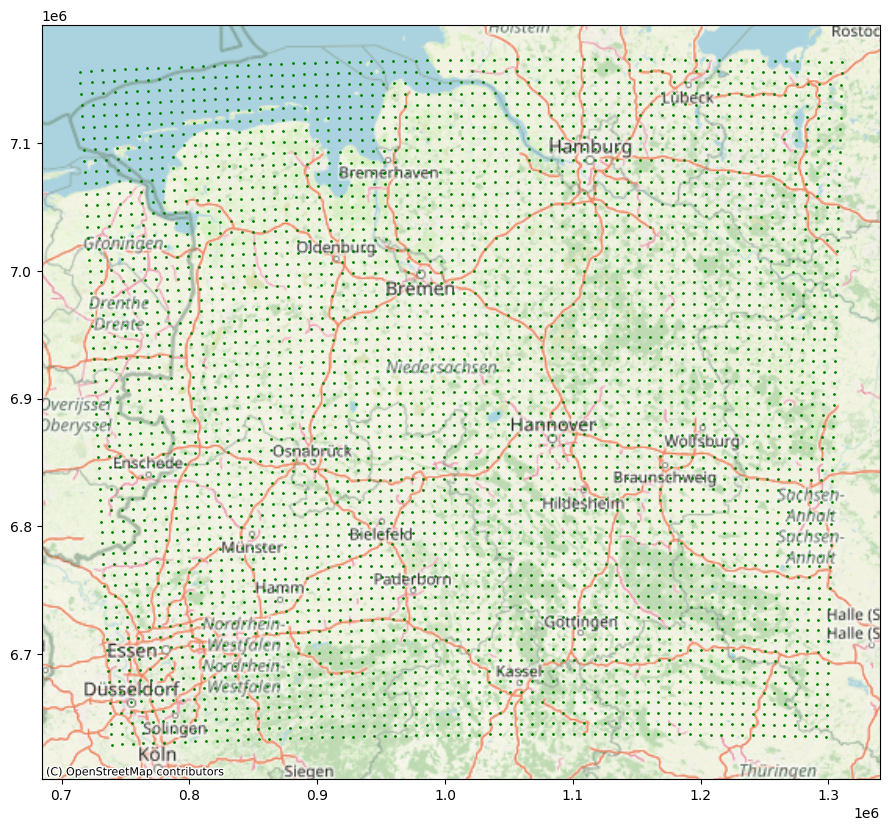

In [4]:
obs_gdf(obs_grid)

### Target observed grid data

In [5]:
import numpy as np
import xarray as xr
import rioxarray

In [6]:
def target_obs_grid (df):
    x_grid = np.sort(df['x'].unique())
    y_grid = np.sort(df['y'].unique())
    target_grid = xr.Dataset(
        coords = {
            'x': x_grid,
            'y': y_grid
        }
    )
    ds_target = target_grid.rio.write_crs('EPSG:3034')
    return ds_target

In [7]:
ds_target = target_obs_grid (obs_grid)
ds_target

<xarray.Dataset> Size: 1kB
Dimensions:      (x: 69, y: 63)
Coordinates:
  * x            (x) int64 552B 3772500 3777500 3782500 ... 4107500 4112500
  * y            (y) int64 504B 2702500 2707500 2712500 ... 3007500 3012500
    spatial_ref  int64 8B 0
Data variables:
    *empty*

In [8]:
from rasterio.enums import Resampling
def regridding_decadal_data(model_data_path, target_grid, model_crs, target_crs):
    ds_model = xr.open_dataset(model_data_path)

    # rename lon and lat to x and y
    if 'lon' in ds_model.dims and 'lat' in ds_model.dims:
        ds_model = ds_model.rename({'lon':'x', 'lat':'y'})
        ds_model = ds_model.rio.set_spatial_dims(x_dim = 'x', y_dim = 'y', inplace = False)

    elif 'x' in ds_model.dims and 'y' in ds_model.dims:
        pass
    else:
        raise ValueError('Dataset missing spatial dimensions (expected lon/lat or x/y).')

    # model crs
    ds_model = ds_model.rio.write_crs(model_crs)

    # reproject 
    ds_model = ds_model.rio.reproject(target_crs)

    # interpolation
    ds_regridded = ds_model.rio.reproject_match(
        target_grid,
        resampling = Resampling.bilinear
    )

    return ds_regridded

### Regridding for all three forecast products ['subseasonal','seasonal','decadal']

In [9]:
from pathlib import Path

In [10]:
# file_path = Path(r'U:\Guests\Pandit\_upload\2026-02-20')
# # forecasts_folders = ['subseasonal','seasonal','decadal']
# forecasts_folders = ['seasonal']
# model_crs = {
#     'subseasonal': 'EPSG:3034',
#     'seasonal': 'EPSG:4326',
#     'decadal': 'EPSG:4326'
# }

# # observation grid
# observation_crs = 'EPSG:3034'


# for folder_name in forecasts_folders:
#     # input path
#     input_dir = file_path / folder_name
#     # # output path
#     output_dir = file_path / f'{folder_name}_regridded'

#     if not input_dir.exists():
#         print(f'Skipping {folder_name} (No data Folder)')
#         continue
#     print(f'Processing forecast_folders {folder_name}')

#     # crs of the model
#     crs_current = model_crs[folder_name]
#     print(f'Model_crs {crs_current}')


#     # variables folder
#     for var_folders in input_dir.iterdir():
#         if var_folders.is_dir():

#             # output folders
#             save_path = output_dir/ var_folders.name
#             save_path.mkdir(parents = True, exist_ok = True)
            
#             # netcdf files
#             nc_files = list(var_folders.glob('*.nc'))
#             # print(f'{var_folders.name}: {len(nc_files)} nc files')
#             # # print(nc_files)

#             if not nc_files:
#                 continue

#             for nc_path in nc_files:
#                 try:
#                     ds_out = regridding_decadal_data(nc_path, ds_target, crs_current, observation_crs)
                    
#                     # 'ds_out = ds_out.where(~np.isnan(ds_out), drop = True)'

#                     # save file
#                     output_file = save_path / nc_path.name
#                     ds_out.to_netcdf(output_file)

#                     # clean
#                     ds_out.close()

#                 except Exception as e:
#                         print(f"! Error on {nc_path.name}: {e}")


# print("\nProcessing Complete.")

### regridding example with one nc file

In [11]:
ds_model = xr.open_dataset(r'U:\Guests\Pandit\_upload\2026-02-20\seasonal\pr\r30_19920401-19921031.nc')

In [12]:
ds_model

<xarray.Dataset> Size: 4MB
Dimensions:  (lon: 71, lat: 61, time: 214)
Coordinates:
  * lon      (lon) float64 568B 6.537 6.612 6.688 6.762 ... 11.64 11.71 11.79
  * lat      (lat) float64 488B 51.02 51.07 51.12 51.17 ... 53.92 53.98 54.02
  * time     (time) datetime64[ns] 2kB 1992-04-01T12:00:00 ... 1992-10-31T12:...
Data variables:
    pr       (time, lat, lon) float32 4MB ...

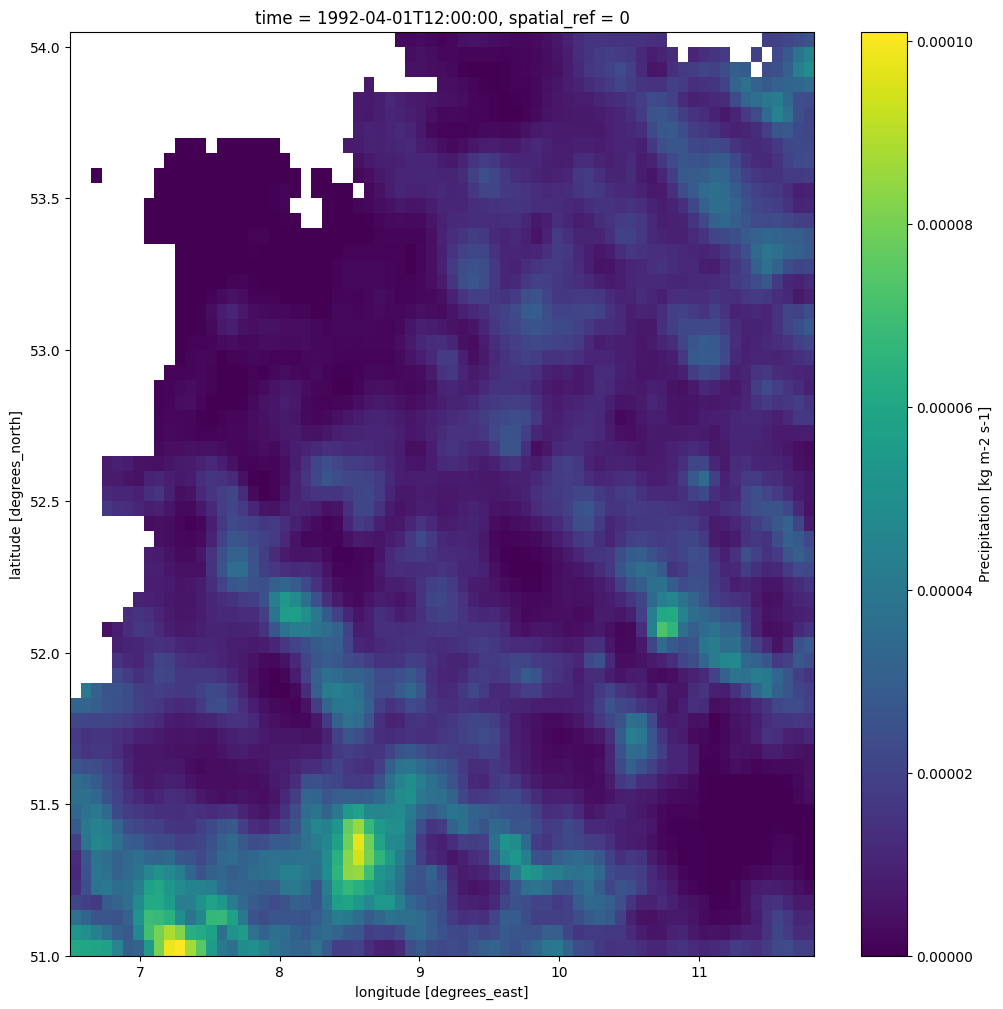

In [13]:
ds_model = ds_model.rio.write_crs('EPSG:4326')
fig, ax = plt.subplots(figsize=(12,12))
ds_model.pr.isel(time= 0).plot(ax = ax)

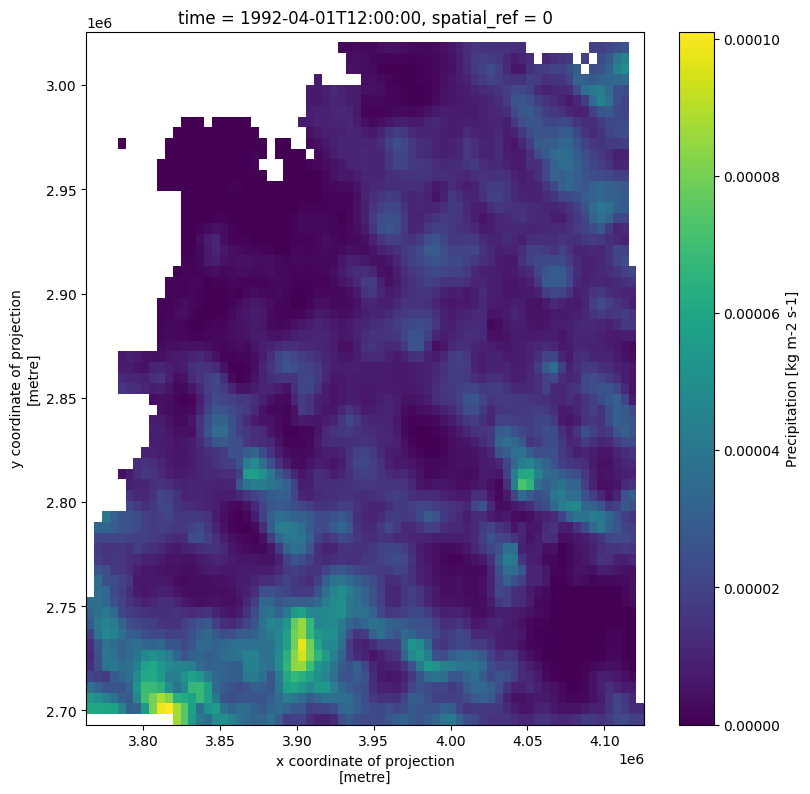

In [14]:
ds_model = ds_model.rename({'lon': 'x', 'lat': 'y'})
ds_model = ds_model.rio.set_spatial_dims(x_dim='x', y_dim='y')

ds_model_3034 = ds_model.rio.reproject('EPSG:3034')
fig, ax = plt.subplots(figsize=(9,9))
ds_model_3034.pr.isel(time= 0).plot(ax = ax)

In [15]:
ds_model_reproject = ds_model_3034.rio.reproject_match(
    ds_target,
    resampling = Resampling.bilinear
)

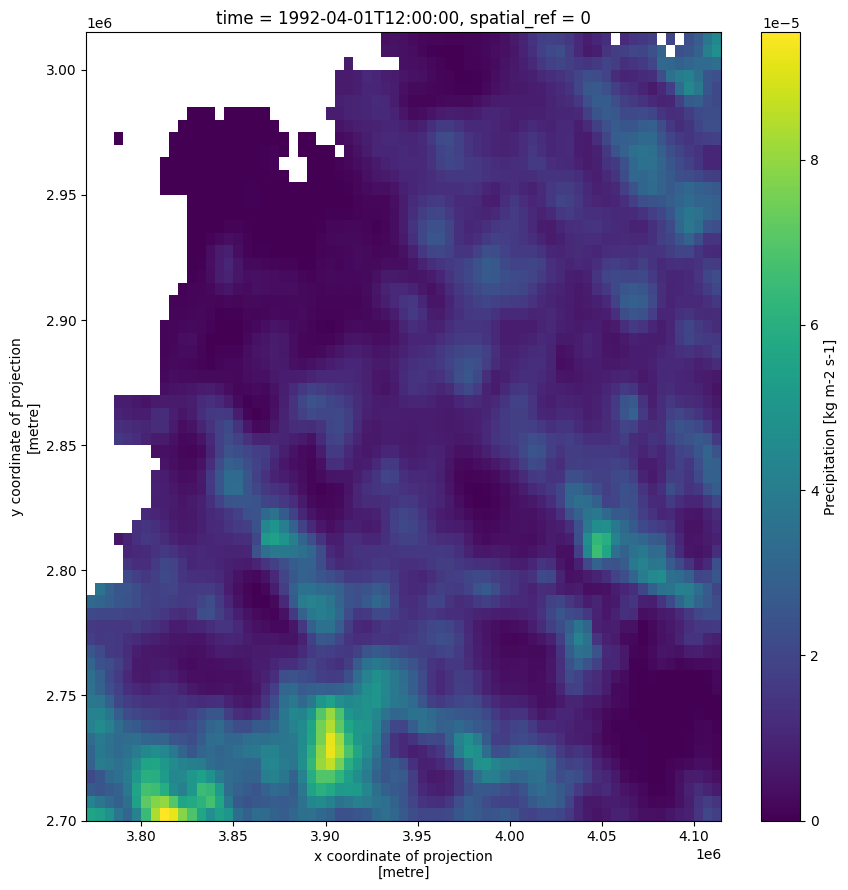

In [16]:
fig, ax = plt.subplots(figsize = (9,9))

ds_model_reproject.pr.isel(time = 0).plot(ax = ax)
plt.tight_layout()
plt.show()